<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Module_19_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score,recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report

# Practice Problems


# 1. Decision Tree: Overfitting vs Underfitting

### Dataset: Iris Dataset (UCI/Kaggle)
### Download: https://www.kaggle.com/datasets/uciml/iris

Tasks
- Load the dataset.
- Split it into 80% training and 20% testing data.
- Train two Decision Tree models:
  - Model A: max_depth=2
  - Model B: max_depth=None

Compare:
- Training Accuracy
- Testing Accuracy

Which model is underfitting? Which one is overfitting?


In [4]:
# Load the dataset.
df_iris = pd.read_csv('Iris.csv')

# Split it into 80% training and 20% testing data.
X = df_iris.drop(['Id', 'Species'], axis = 1)
y = df_iris['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Train two Decision Tree models:
# Model A: max_depth=2
Model_A = DecisionTreeClassifier(max_depth = 2)
Model_A.fit(X_train, y_train)

# Model B: max_depth=None
Model_B = DecisionTreeClassifier(max_depth= None)
Model_B.fit(X_train, y_train)

# Compare: Training Accuracy, Testing Accuracy
model_a_pred_train = Model_A.predict(X_train)
print('Model A Train Accuracy:', accuracy_score(y_train, model_a_pred_train))
model_a_pred_test = Model_A.predict(X_test)
print('Model A Test Accuracy:', accuracy_score(y_test, model_a_pred_test))

print()

model_b_pred_train = Model_B.predict(X_train)
print('Model B Train Accuracy:', accuracy_score(y_train, model_b_pred_train))
model_b_pred_test = Model_B.predict(X_test)
print('Model B Test Accuracy:', accuracy_score(y_test, model_b_pred_test))

# Which model is underfitting? Which one is overfitting?
# Ans: Model A: Underfitting, Model B: Overfitting

Model A Train Accuracy: 0.9666666666666667
Model A Test Accuracy: 0.9333333333333333

Model B Train Accuracy: 1.0
Model B Test Accuracy: 0.9666666666666667


# 2. Finding the Best Tree Depth

### Dataset: Wine Dataset
### Download: https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009

Tasks
- Load the dataset.
- Train Decision Trees using:
  - depth = 2
  - depth = 4
  - depth = 6
  - depth = 8
  - depth = None

Create a table containing:
- max_depth
- Train Accuracy
- Test Accuracy

Which depth gives the best generalization?


In [5]:
# Load the dataset.
df_wine = pd.read_csv('winequality-red.csv')

X = df_wine.drop('quality', axis = 1)
y = df_wine['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# Train Decision Trees using: depth = 2, depth = 6, depth = 8, depth = 4, depth = None

# ====================================================================================
# Method - 1
# model1 = DecisionTreeClassifier(max_depth = 2)
# model1.fit(X_train, y_train)

# model2 = DecisionTreeClassifier(max_depth = 6)
# model2.fit(X_train, y_train)

# model3 = DecisionTreeClassifier(max_depth = 8)
# model3.fit(X_train, y_train)

# model4 = DecisionTreeClassifier(max_depth = 4)
# model4.fit(X_train, y_train)

# model5 = DecisionTreeClassifier(max_depth = None)
# model5.fit(X_train, y_train)
# ====================================================================================

# ====================================================================================
# Method - 2 (Loop)
depths = [2, 6, 8, 4, None]
result = []

for depth in depths:
  model = DecisionTreeClassifier(max_depth = depth)
  model.fit(X_train, y_train)

  train_acc = accuracy_score(y_train, model.predict(X_train))
  test_acc = accuracy_score(y_test, model.predict(X_test))

  result.append({'max_depth': depth, 'Training Accuracy': round(train_acc, 4), 'Test Accuracy': round(test_acc, 4)})


# Create a table containing: max_depth, Train Accuracy, Test Accuracy
df_result = pd.DataFrame(result)
print(df_result.to_string(index = False))

# Which depth gives the best generalization?
# Ans: By looking at the table, we can say that the depth 6 provides the best generalization which is 0.5750 although the None depth has train accuracy of 100% despite of data overfitting.

# by code (excluding None to avoid overfitting pick)
df_limited = df_result[df_result['max_depth'].notna()]
best = df_limited.loc[df_limited['Test Accuracy'].idxmax()]
print(f"\nBest generalization at max_depth = {int(best['max_depth'])} with Test Accuracy = {best['Test Accuracy']}")

 max_depth  Training Accuracy  Test Accuracy
       2.0             0.5700         0.5125
       6.0             0.7123         0.5750
       8.0             0.8022         0.5781
       4.0             0.6302         0.5625
       NaN             1.0000         0.6062

Best generalization at max_depth = 8 with Test Accuracy = 0.5781


# 3. Random Forest vs Decision Tree

### Dataset: Breast Cancer Wisconsin Dataset
### Download: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

Tasks
- Train a Decision Tree.
- Train a Random Forest (n_estimators=100).

Compare:
- Accuracy
- Precision
- Recall

Which model performs better and why?


In [6]:
# load dataset
df_cancer = pd.read_csv('data.csv')

X = df_cancer.drop(['id', 'diagnosis', 'Unnamed: 32'], axis=1)
y = df_cancer['diagnosis']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train a Decision Tree
deci_model = DecisionTreeClassifier()
deci_model.fit(X_train, y_train)
dt_pred = deci_model.predict(X_test)

# Train a Random Forest (n_estimators=100)
grid_param_RF = {
    'n_estimators': [100],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2'],
}
grid_search_RF = GridSearchCV(
    estimator=RandomForestClassifier(),
    param_grid=grid_param_RF,
    cv=5
    )

grid_search_RF.fit(X_train, y_train)
rf_pred = grid_search_RF.predict(X_test)

# Compare: Accuracy, Precision, Recall

print(f"Decision Tree:  Accuracy: {round(accuracy_score(y_test, dt_pred), 2)}, Recall: {round(recall_score(y_test, dt_pred), 2)}, Precision: {round(precision_score(y_test, dt_pred), 2)}")
print(f"Random Forest: Accuracy: {round(accuracy_score(y_test, rf_pred), 2)}, Recall: {round(recall_score(y_test, rf_pred), 2)}, Precision: {round(precision_score(y_test, rf_pred), 2)}")

# Which model performs better and why?
# Ans: Random Forest performs better because instead of relying on a single
# decision tree, it builds multiple trees and takes a majority vote — reducing
# overfitting and improving generalization.

Decision Tree:  Accuracy: 0.92, Recall: 0.9, Precision: 0.88
Random Forest: Accuracy: 0.96, Recall: 0.9, Precision: 1.0


# 4. Effect of Number of Trees
###Dataset: Heart Disease Dataset
### Download: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

Tasks
- Train Random Forest with:
  - 10 trees
  - 50 trees
  - 100 trees
  - 200 trees

- Create a comparison table of:
  - Number of Trees
  - Train Accuracy
  - Test Accuracy
  - Training Time

Which number of trees gives the best balance between performance and computation?


In [7]:


# Load dataset
df_heart = pd.read_csv('heart.csv')

X = df_heart.drop('target', axis=1)
y = df_heart['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

results = []

for n in [10, 50, 100, 200]:
    grid_search = GridSearchCV(
        estimator=RandomForestClassifier(n_estimators=n, random_state=42),
        param_grid={},
        cv=5
    )

    start = time.time()
    grid_search.fit(X_train, y_train)
    elapsed = round(time.time() - start, 4)

    train_acc = round(accuracy_score(y_train, grid_search.predict(X_train)), 4)
    test_acc  = round(accuracy_score(y_test,  grid_search.predict(X_test)),  4)

    results.append({'N Trees': n, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc, 'Training Time(s)': elapsed})

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Which gives best balance?
# Ans: 100 trees — accuracy stabilizes here, 200 trees adds minimal
# improvement but increases training time significantly.

 N Trees  Train Accuracy  Test Accuracy  Training Time(s)
      10             1.0            1.0            0.1420
      50             1.0            1.0            0.5924
     100             1.0            1.0            1.5429
     200             1.0            1.0            3.0309


# 5. Understanding Bias-Variance Tradeoff
### Dataset: Titanic Dataset
### Download: https://www.kaggle.com/competitions/titanic/data

Tasks

Train the following models:
- Decision Tree (depth=2)
- Decision Tree (depth=10)
- Random Forest (100 trees)

Compare:
- Training Accuracy
- Testing Accuracy

For each model determine:
- High Bias?
- High Variance?
- Balanced?

Explain your reasoning.


In [8]:
# load dataset
df_titanic = pd.read_csv('train.csv')

df_titanic = df_titanic.select_dtypes(include='number').dropna()

X = df_titanic.drop('Survived', axis=1)
y = df_titanic['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train the following models:
# Decision Tree (depth=2)
dec_mod1 = DecisionTreeClassifier(max_depth = 2, random_state = 42)
dec_mod1.fit(X_train, y_train)

# Decision Tree (depth=10)
dec_mod2 = DecisionTreeClassifier(max_depth = 10, random_state = 42)
dec_mod2.fit(X_train, y_train)

# Random Forest (100 trees)
rf_mod = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_mod.fit(X_train, y_train)

# Compare: Training Accuracy, Testing Accuracy
results = pd.DataFrame({
    'Model':            ['DT depth=2', 'DT depth=10', 'RF 100 trees'],
    'Train Accuracy':   [round(accuracy_score(y_train, dec_mod1.predict(X_train)), 4),
                         round(accuracy_score(y_train, dec_mod2.predict(X_train)), 4),
                         round(accuracy_score(y_train, rf_mod.predict(X_train)),   4)],

    'Test Accuracy':    [round(accuracy_score(y_test, dec_mod1.predict(X_test)), 4),
                         round(accuracy_score(y_test, dec_mod2.predict(X_test)), 4),
                         round(accuracy_score(y_test, rf_mod.predict(X_test)),   4)],
})

print(results.to_string(index=False))

# For each model determine: High Bias? High Variance? Balanced?
# Ans: Decision Tree (depth=2) → High Bias because its Too shallow to learn the data properly. Both train and test accuracy will be low. Underfitting.
# Decision Tree (depth=10) → High Variance because its Too deep, memorizes training data. Train accuracy very high but test accuracy drops. Overfitting.
# Random Forest (100 trees) → Balanced because it Combines many trees and averages results, reducing overfitting. Both train and test accuracy will be high and close to each other.

       Model  Train Accuracy  Test Accuracy
  DT depth=2          0.7110         0.6993
 DT depth=10          0.9194         0.5524
RF 100 trees          1.0000         0.6783


# 6. Visualizing Overfitting
### Dataset: Pima Indians Diabetes Dataset
### Download: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

Tasks
- Train Decision Trees for every depth from:
  - 1 to 20

Create a graph:
  - X-axis → Tree Depth
  - Y-axis → Accuracy

Plot both:
  - Training Accuracy
  - Testing Accuracy

Questions:
 - At which depth does overfitting begin?
- Why?


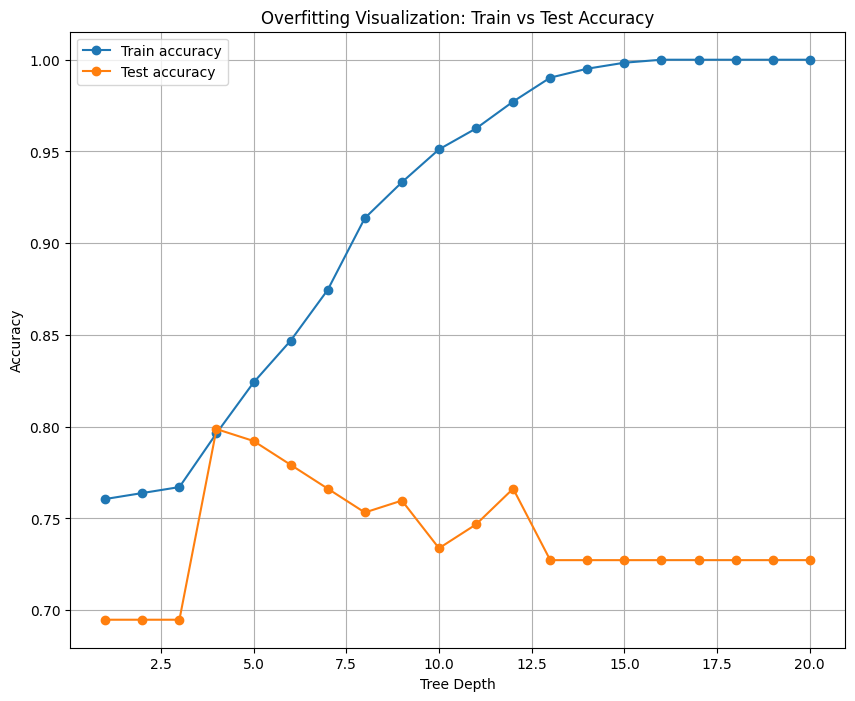


 Max Depth  Train Accuracy  Test Accuracy
         1        0.760586       0.694805
         2        0.763844       0.694805
         3        0.767101       0.694805
         4        0.796417       0.798701
         5        0.824104       0.792208
         6        0.846906       0.779221
         7        0.874593       0.766234
         8        0.913681       0.753247
         9        0.933225       0.759740
        10        0.951140       0.733766
        11        0.962541       0.746753
        12        0.977199       0.766234
        13        0.990228       0.727273
        14        0.995114       0.727273
        15        0.998371       0.727273
        16        1.000000       0.727273
        17        1.000000       0.727273
        18        1.000000       0.727273
        19        1.000000       0.727273
        20        1.000000       0.727273


In [28]:
# load dataset
df_diab = pd.read_csv('diabetes.csv')

X = df_diab.drop('Outcome', axis = 1)
y = df_diab['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify = y)

# Train Decision Trees for every depth from: 1 to 20
results = []

for i in range(1, 21):
  model = DecisionTreeClassifier(max_depth=i, random_state=42)
  model.fit(X_train, y_train)

  y_pred_train = model.predict(X_train)
  y_pred_test = model.predict(X_test)

  train_acc = accuracy_score(y_train, y_pred_train)
  test_acc = accuracy_score(y_test, y_pred_test)

  results.append({'Max Depth': i, 'Train Accuracy': train_acc, 'Test Accuracy': test_acc})

df_results = pd.DataFrame(results)

# Create a graph: X-axis → Tree Depth, Y-axis → Accuracy
plt.figure(figsize = (10, 8))
plt.plot(df_results['Max Depth'], df_results['Train Accuracy'], marker = 'o', label = 'Train accuracy')
plt.plot(df_results['Max Depth'], df_results['Test Accuracy'], marker = 'o', label = 'Test accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Overfitting Visualization: Train vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print()

print(df_results.to_string(index=False))

# Questions: At which depth does overfitting begin? Why?
# Ans: The depth does overfitting at 4 - 7 because the train accuracy increases but the test accuracy begin to fall. This means the model is memorizing the train data
# instead of generalizing.

# 7. Hyperparameter Tuning of Random Forest
### Dataset: Adult Income Dataset
### Download: https://www.kaggle.com/datasets/uciml/adult-census-income

Tasks

Perform Grid Search on:
- n_estimators:
  - 50
  - 100
  - 200

- max_depth:
  - 5
  - 10
  - 20
  - None

- max_features:
  - sqrt
  - log2

Find the best model.

Report:
- Best Parameters
- Best Cross Validation Score
- Test Accuracy


In [39]:
# load dataset
df_adult = pd.read_csv('adult.csv')

X = df_adult.drop('income', axis = 1)
y = df_adult['income']

X = pd.get_dummies(X, drop_first=True)
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify = y)

# Perform Grid Search on: n_estimators: 50, 100, 200, max_depth: 5, 10, 20, None, max_features: sqrt, log2
grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    estimator = RandomForestClassifier(random_state = 42),
    param_grid = grid,
    cv = 5
)
grid_search.fit(X_train, y_train)

y_pred_train = grid_search.predict(X_train)
y_pred_test = grid_search.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f'Train Accuracy: {round(train_acc, 2)}, Test Accuracy: {round(test_acc, 2)}')

# Find the best model.
# Report: Best Parameters, Best Cross Validation Score, Test Accuracy
best_param = grid_search.best_params_
best_cv_score = grid_search.best_score_

print('Best Parameters:', best_param)
print('Best Cross Validation score:', best_cv_score)
print('Test Accuracy:', round(test_acc, 2))

Train Accuracy: 0.92, Test Accuracy: 0.86
Best Parameters: {'max_depth': 20, 'max_features': 'sqrt', 'n_estimators': 200}
Best Cross Validation score: 0.8645960833328115
Test Accuracy: 0.86


# 8. Feature Importance Analysis
### Dataset: Bank Marketing Dataset
### Download: https://www.kaggle.com/datasets/henriqueyamahata/bank-marketing

Tasks

Train a Random Forest.
- Find:
  - Top 10 Important Features
  - Create a bar chart showing feature importance.

Questions:
- Which feature contributes the most?
- Which features contribute the least?
- Remove the least important 5 features and retrain the model.
- Does accuracy change?


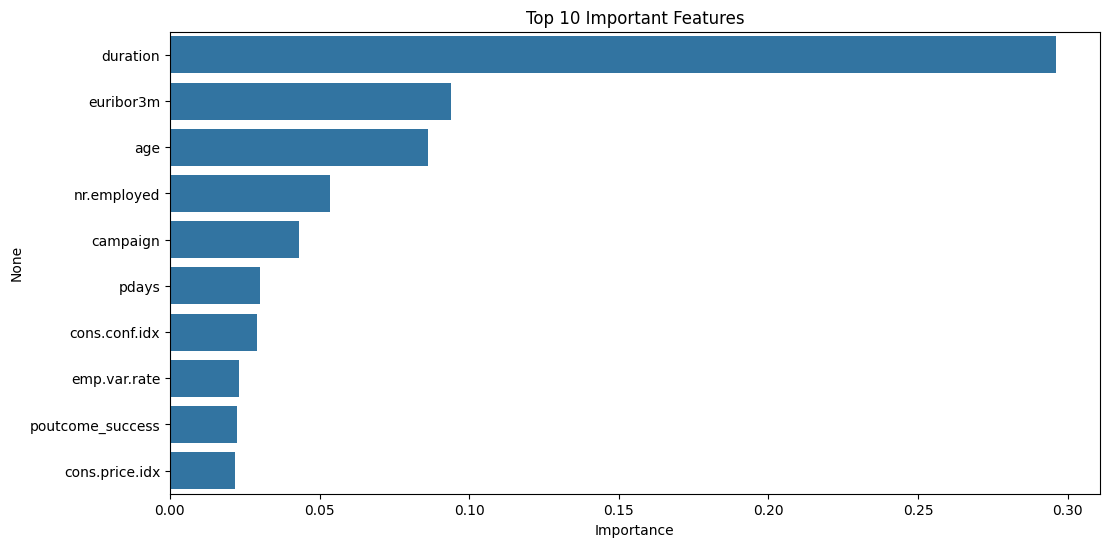


Least Important 5 Features: 
 job_unknown             1.739515e-03
month_dec               7.130972e-04
marital_unknown         4.936842e-04
education_illiterate    2.618459e-04
default_yes             7.099797e-09
dtype: float64

Original Accuracy: 0.9153
Reduced Accuracy:  0.9168

Yes, Accuracy Increases


In [54]:
# load dataset
df_bank = pd.read_csv('bank-additional-full.csv', sep = ';')

X = df_bank.drop('y', axis = 1)
y = df_bank['y']

X = pd.get_dummies(X, drop_first = True)
le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify = y)

# Train a Random Forest.
model_rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
model_rf.fit(X_train, y_train)
y_train_pred = model_rf.predict(X_train)
y_test_pred = model_rf.predict(X_test)

base_acc = accuracy_score(y_test, y_test_pred)

# Top 10 Important Features
importances = pd.Series(model_rf.feature_importances_, index = X_train.columns)
sorted_importances = importances.sort_values(ascending=False)
top_10 = sorted_importances.head(10)

# Create a bar chart showing feature importance.
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10.values, y=top_10.index)
plt.title('Top 10 Important Features')
plt.xlabel('Importance')
plt.show()

print()

# Which feature contributes the most?
# Ans: Duration

# Which features contribute the least?
least_5 = sorted_importances.tail(5)
print('Least Important 5 Features: \n', least_5)

# Remove the least important 5 features and retrain the model.
least_features = least_5.index.tolist()
X_train_reduced = X_train.drop(least_features, axis = 1)
X_test_reduced = X_test.drop(least_features, axis = 1)

model_rf_reduced = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_reduced.fit(X_train_reduced, y_train)
y_test_pred_reduced = model_rf_reduced.predict(X_test_reduced)

reduced_acc = accuracy_score(y_test, y_test_pred_reduced)

print(f'\nOriginal Accuracy: {round(base_acc, 4)}')
print(f'Reduced Accuracy:  {round(reduced_acc, 4)}')

print()

# Does accuracy change?
if (reduced_acc > base_acc):
  print('Yes, Accuracy Increases')
elif (reduced_acc < base_acc):
  print('Yes, Accuracy Decreases')
elif (reduced_acc == base_acc):
  print('No, Accuracy remains same')

# 9. Decision Tree Pruning for Better Generalization
### Dataset: Telco Customer Churn Dataset
### Download: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

Tasks

Train three Decision Trees:
- No pruning
- max_depth=6
- min_samples_leaf=10

Compare:
- Training Accuracy
- Testing Accuracy
- Precision
- Recall
- F1 Score

Explain which pruning strategy improves generalization the most.


In [70]:
# load dataset
df_churn = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

X = df_churn.drop(['customerID', 'Churn'], axis = 1)
y = df_churn['Churn']

X = pd.get_dummies(X, drop_first=True)

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify = y)

# Train three Decision Trees:
# No pruning, max_depth=6, min_samples_leaf=10
model1 = DecisionTreeClassifier(max_depth = None,  ccp_alpha=0.0, random_state = 42)
model1.fit(X_train, y_train)
y_train_pred_m1 = model1.predict(X_train)
y_test_pred_m1 = model1.predict(X_test)

model2 = DecisionTreeClassifier(max_depth = 6, random_state = 42)
model2.fit(X_train, y_train)
y_train_pred_m2 = model2.predict(X_train)
y_test_pred_m2 = model2.predict(X_test)

model3 = DecisionTreeClassifier(min_samples_leaf=10, random_state = 42)
model3.fit(X_train, y_train)
y_train_pred_m3 = model3.predict(X_train)
y_test_pred_m3 = model3.predict(X_test)


m1_train_acc = accuracy_score(y_train, y_train_pred_m1)
m1_test_acc = accuracy_score(y_test, y_test_pred_m1)

m2_train_acc = accuracy_score(y_train, y_train_pred_m2)
m2_test_acc = accuracy_score(y_test, y_test_pred_m2)

m3_train_acc = accuracy_score(y_train, y_train_pred_m3)
m3_test_acc = accuracy_score(y_test, y_test_pred_m3)

print('Model 1 Training Accuracy:', round(m1_train_acc, 2))
print('Model 1 Testing Accuracy:', round(m1_test_acc, 2))
print()

print('Model 2 Training Accuracy:', round(m2_train_acc, 2))
print('Model 2 Testing Accuracy:', round(m2_test_acc, 2))
print()

print('Model 3 Training Accuracy:', round(m3_train_acc, 2))
print('Model 3 Testing Accuracy:', round(m3_test_acc, 2))
print()

print('Model 1 Report: \n' ,classification_report(y_test,y_test_pred_m1))
print()

print('Model 2 Report: \n' ,classification_report(y_test,y_test_pred_m2))
print()

print('Model 3 Report: \n' ,classification_report(y_test,y_test_pred_m3))


# Explain which pruning strategy improves generalization the most.
# Ans: Compare the gap between Train Accuracy and Test Accuracy for each model:
# - Model 1 (No pruning) → typically has Train Acc ~100% but lower Test Acc → overfitting
# - Model 2 (max_depth=6) → smaller train-test gap, more balanced
# - Model 3 (min_samples_leaf=10) → also reduces overfitting by preventing tiny leaf nodes
# Whichever model has the HIGHEST test accuracy AND smallest train-test gap generalizes best. Typically max_depth=6 or min_samples_leaf=10 will outperform
# the unpruned tree, since pruning controls overfitting and improves performance on unseen data.

Model 1 Training Accuracy: 1.0
Model 1 Testing Accuracy: 0.76

Model 2 Training Accuracy: 0.81
Model 2 Testing Accuracy: 0.8

Model 3 Training Accuracy: 0.85
Model 3 Testing Accuracy: 0.77

Model 1 Report: 
               precision    recall  f1-score   support

           0       0.82      0.86      0.84      1035
           1       0.55      0.49      0.52       374

    accuracy                           0.76      1409
   macro avg       0.69      0.67      0.68      1409
weighted avg       0.75      0.76      0.75      1409


Model 2 Report: 
               precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.49      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409


Model 3 Report: 
               precision    recall  f1-score   support

           0       0.83      0.88      0.85  

# 10. Bias-Variance Analysis Across Multiple Models
### Dataset: Dry Bean Dataset
### Download: https://www.kaggle.com/datasets/muratkokludataset/dry-bean-dataset

Tasks

Train the following models:
- Decision Tree (max_depth=3)
- Decision Tree (max_depth=None)
- Random Forest (n_estimators=100)
- Random Forest (n_estimators=300)

Create a comparison table containing:
- Training Accuracy
- Testing Accuracy
- Estimated Bias (High/Low)
- Estimated Variance (High/Low)

Finally, answer:
- Which model has the highest bias?
- Which model has the highest variance?
- Which model generalizes the best?
- Why does Random Forest usually outperform a single Decision Tree?
- Explain the relationship between ensemble learning and the Bias-Variance Tradeoff based on your experimental results.


In [80]:
# load dataset
df_beans = pd.read_excel('Dry_Bean_Dataset.xlsx')

X = df_beans.drop('Class', axis = 1)
y = df_beans['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify = y)

# Train the following models:
# Decision Tree (max_depth=3), Decision Tree (max_depth=None)

results = []

for d in [3, None]:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    name = f'Decision Tree (depth={d})'
    results.append({'Model': name, 'Train Accuracy': round(train_acc, 4), 'Test Accuracy': round(test_acc, 4)})

# Random Forest (n_estimators=100), Random Forest (n_estimators=300)
for n in [100, 300]:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    name = f'Random Forest (n={n})'
    results.append({'Model': name, 'Train Accuracy': round(train_acc, 4), 'Test Accuracy': round(test_acc, 4)})

# Create a comparison table containing: Training Accuracy, Testing Accuracy, Estimated Bias (High/Low), Estimated Variance (High/Low)
df_results = pd.DataFrame(results)
df_results['Estimated Bias'] = ['High', 'Low', 'Low', 'Low']
df_results['Estimated Variance'] = ['Low', 'High', 'Low', 'Low']
print(df_results.to_string(index=False))

# Finally, answer:

# Which model has the highest bias?
# Ans: Decision tree with depth 3

# Which model has the highest variance?
# Ans: Decision tree with depth None

# Which model generalizes the best?
# Ans: Random forest witn n = 300

# Why does Random Forest usually outperform a single Decision Tree?
# Ans: Because it takes decision from multiple decision trees instead of a specific one

# Explain the relationship between ensemble learning and the Bias-Variance Tradeoff based on your experimental results.
# Ans: A single deep Decision Tree (depth=None) achieves low bias (100% train accuracy) but high variance (large train-test gap), since it overfits to
# specific training samples. Random Forest, an ensemble method, trains many such low-bias/high-variance trees on random subsets of data and features,
# then averages their predictions. This averaging cancels out individual trees' errors, significantly reducing variance while keeping bias low —
# resulting in better generalization, as seen in Random Forest's higher test accuracy and smaller train-test gap compared to the single deep tree.

                     Model  Train Accuracy  Test Accuracy Estimated Bias Estimated Variance
   Decision Tree (depth=3)          0.7783         0.7730           High                Low
Decision Tree (depth=None)          1.0000         0.8920            Low               High
     Random Forest (n=100)          1.0000         0.9203            Low                Low
     Random Forest (n=300)          1.0000         0.9210            Low                Low
